# tmp — jun25

**Motivation**: scratch notebook <br>

In [1]:
# HIDE CODE


import os, sys
from IPython.display import display

# tmp & extras dir
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
extras_dir = os.path.join(git_dir, 'jb-vae/_extras')
fig_base_dir = os.path.join(git_dir, 'jb-vae/figs')
tmp_dir = os.path.join(git_dir, 'jb-vae/tmp')

# GitHub
sys.path.insert(0, os.path.join(git_dir, '_iclr_ipvae'))
from main.config_defaults import default_configs
from figures.convergence import plot_convergence
from figures.fighelper import *
from main.train import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
device_idx = 1
device = f'cuda:{device_idx}'

print(f"device: {device}  ———  host: {os.uname().nodename}")

device: cuda:1  ———  host: chewie

## SfN results

### mnist

### vH16

In [3]:
results_sfn = {
    ('conv', 1): (0.85, 0.75),
    ('conv', 2): (0.85, 0.75),
    ('conv', 4): (0.84, 0.76),
    ('conv', 8): (0.80, 0.78),
    ('lin', 1): (0.80, 0.79),
    ('lin', 2): (0.81, 0.78),
    ('lin', 4): (0.82, 0.78),
    ('lin', 8): (0.79, 0.80),
}

In [6]:
distances = {
    k: np.sqrt((1-r2)**2 + ((1-sprs)**2))
    for k, (r2, sprs) in results_sfn.items()
}
print(distances)

{
    ('conv', 1): 0.29154759474226505,
    ('conv', 2): 0.29154759474226505,
    ('conv', 4): 0.2884441020371192,
    ('conv', 8): 0.29732137494637007,
    ('lin', 1): 0.2899999999999999,
    ('lin', 2): 0.2906888370749726,
    ('lin', 4): 0.28425340807103794,
    ('lin', 8): 0.2899999999999999
}

In [7]:
avg_results = collections.defaultdict(list)

for (dec, beta), d in distances.items():
    avg_results[dec].append(d)
    
avg_results = {k: np.mean(v) for k, v in avg_results.items()}
print(avg_results)

{'conv': 0.29221516661700486, 'lin': 0.2887355612865026}

In [4]:
# a = 'poisson_MNIST_t-10_b-5_k-128_<ngd|mlp>'
# b = 'b200-ep400-lr(0.002)_temp(0.05:0.5)_gr(50)_Phase7TestFinal+n_exp_p=1e-3+MLP_(2025_05_27,23:39)'
# tr, meta = load_model_main(a, b, device=device)
# meta['checkpoint']

In [5]:
tr._setup_writer()

Warning: Could not save code info: Reference at 'refs/heads/main' does not exist

In [6]:
results, figs = tr.validate(gstep=123)
list(figs)

['dec', 'recon', 'generated_samples', 'generation_across_time']

dec

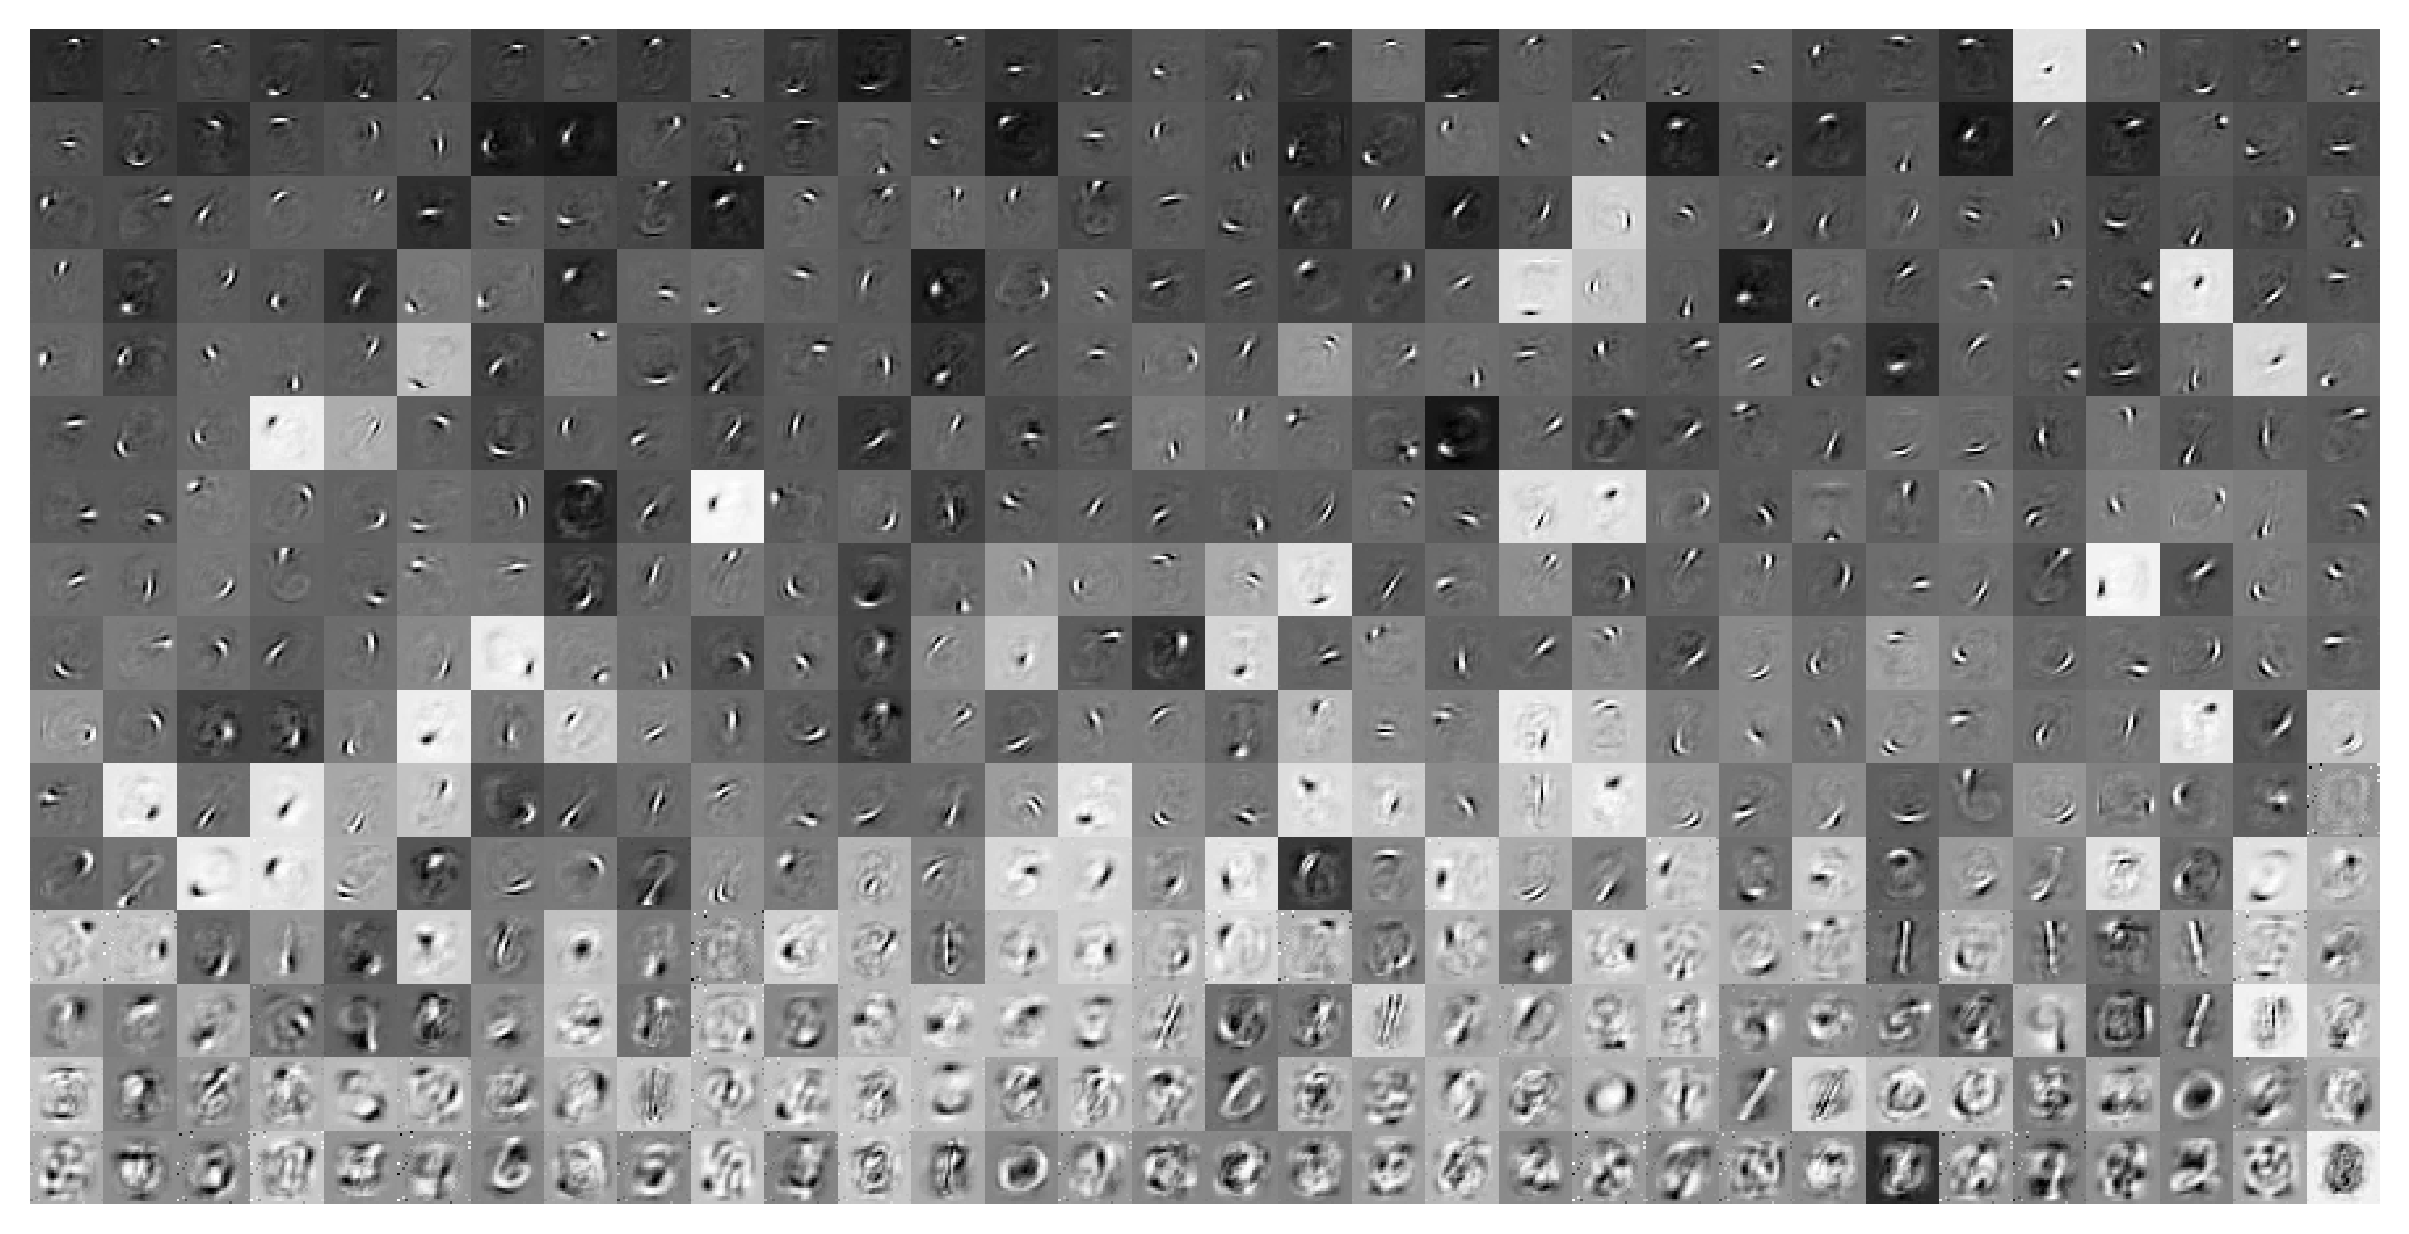

recon

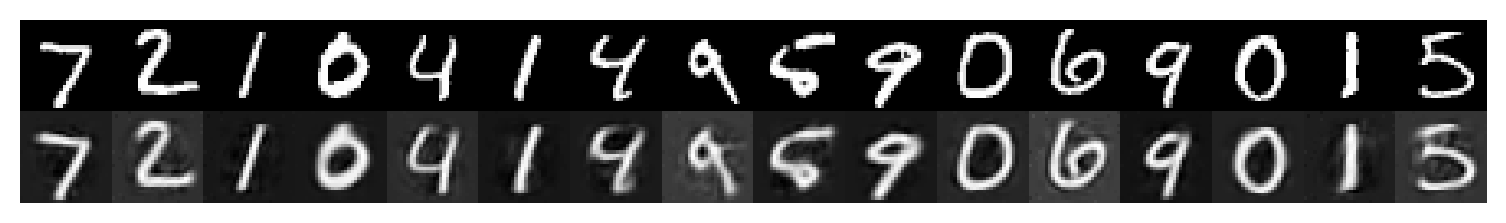

generated_samples

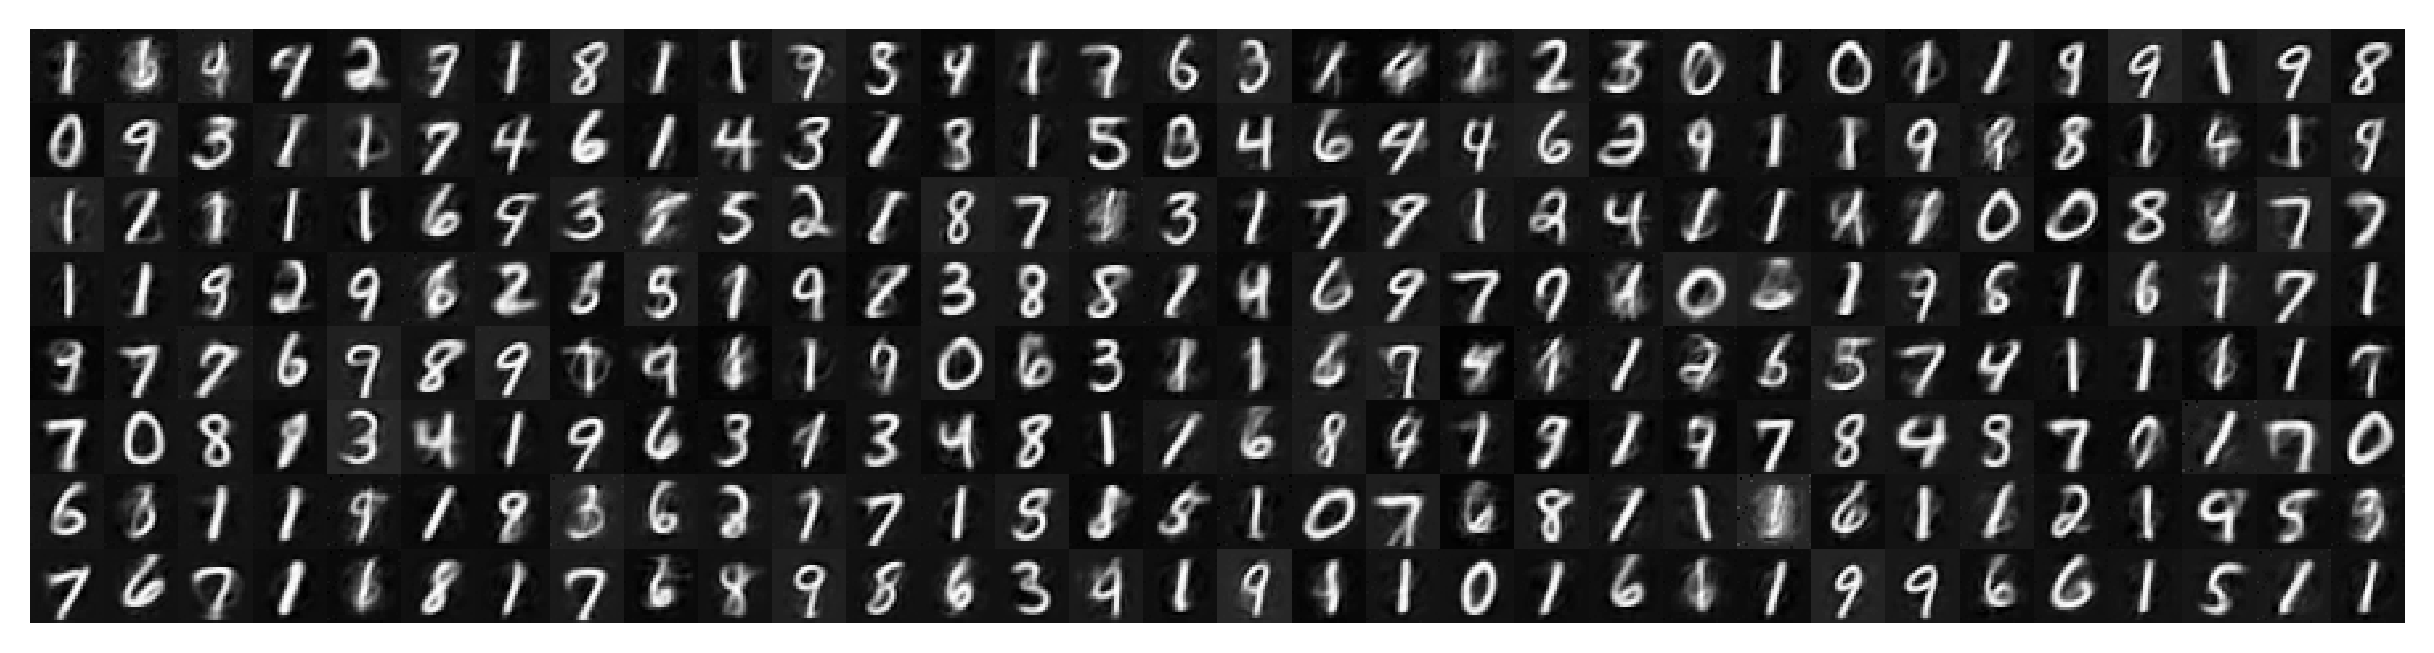

generation_across_time

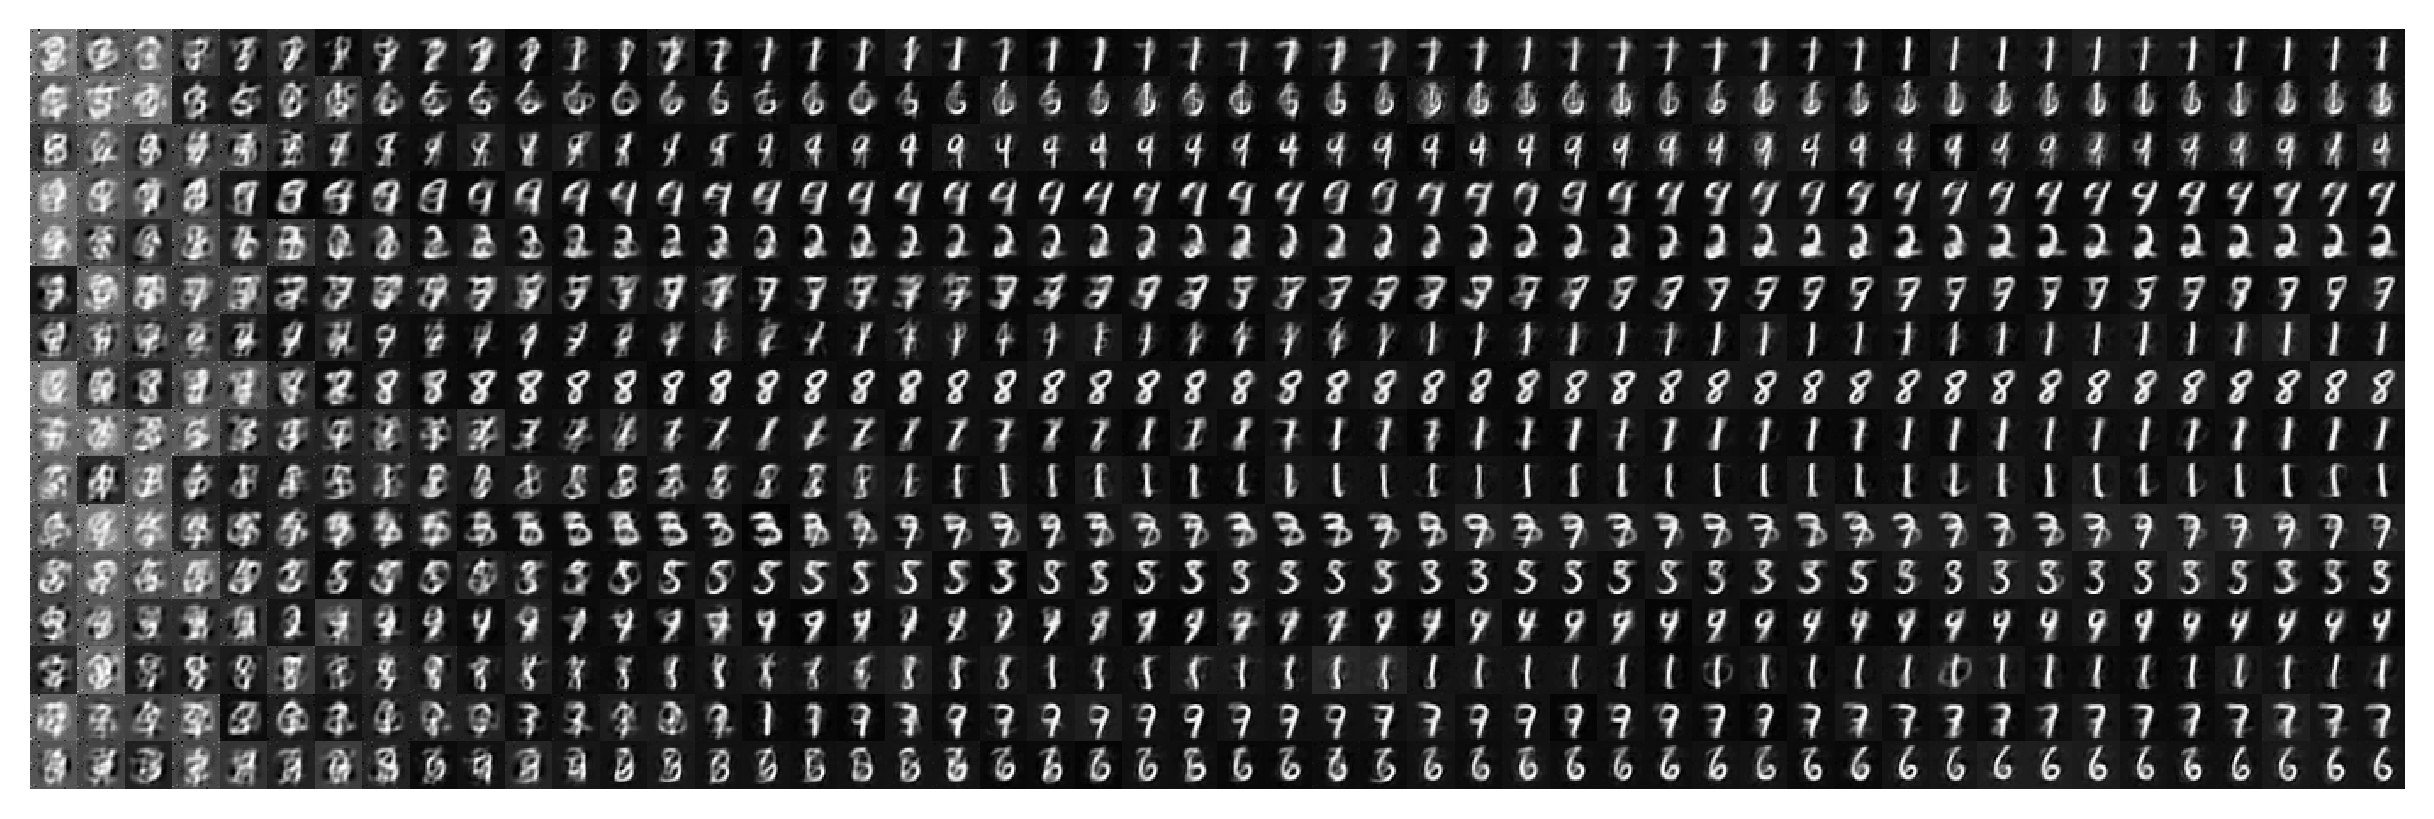

In [7]:
for k, v in figs.items():
    print(k)
    display(v)

100%|█████████████████████████████████| 50/50 [01:54<00:00,  2.29s/it]


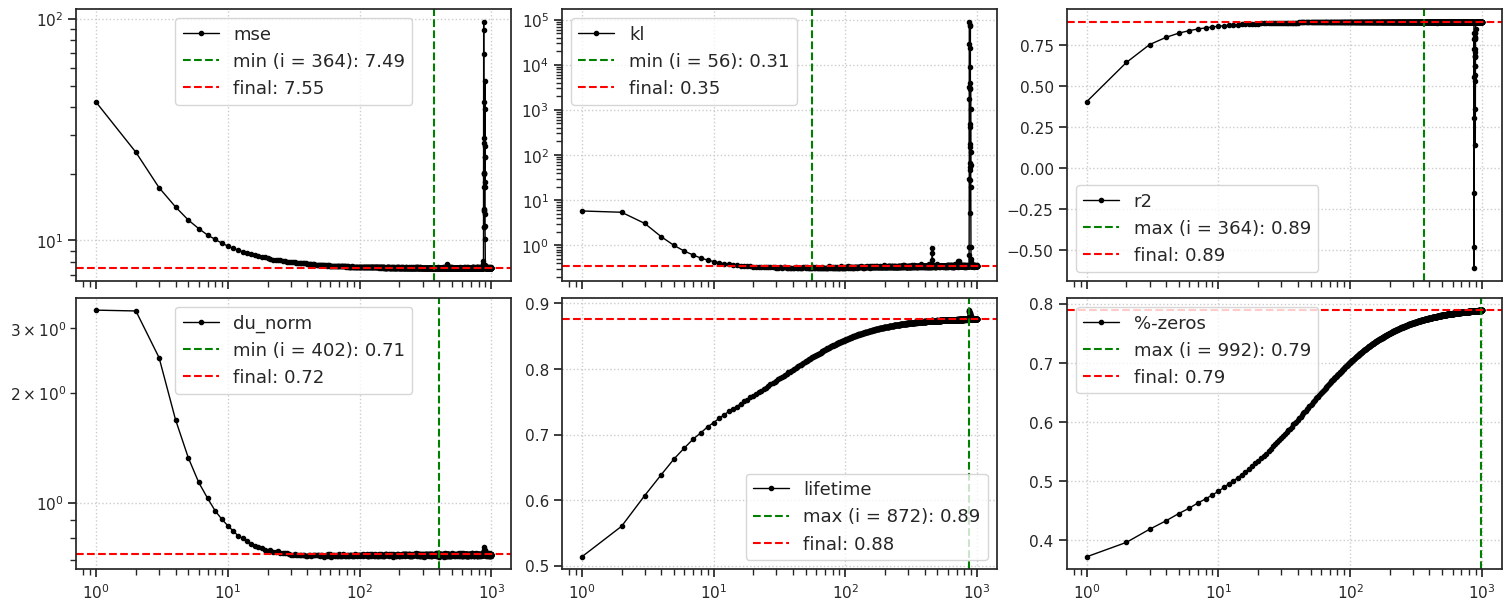

CPU times: user 2min 1s, sys: 1.4 s, total: 2min 3s
Wall time: 2min 2s


wandb: WARNING Fatal error while uploading data. Some run data will not be synced, but it will still be written to disk. Use `wandb sync` at the end of the run to try uploading.


In [8]:
%%time

kws = dict(
    t_total=1000,
    n_data_batches=-1,
    compute_sprs=True,
)
results = tr.analysis('vld', **kws)
_ = plot_convergence(results, color='k')

In [12]:
tr.model.create_chkpt_dir(tr.fit_name)

In [13]:
tr._setup_writer()

/home/hadi/Dropbox/git/_iclr_ipvae

wandb: ERROR Failed to detect the name of this notebook. You can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.


Warning: Could not save code info: Reference at 'refs/heads/main' does not exist

Warning: Could not save notebook info: Can't identify the notebook path.

wandb: WARNING Fatal error while uploading data. Some run data will not be synced, but it will still be written to disk. Use `wandb sync` at the end of the run to try uploading.


In [8]:
model_type = 'poisson'
cfg_vae, cfg_tr = default_configs('MNIST', model_type, 'ngd|mlp')

cfg_vae['t_train'] = 16
cfg_vae['kl_beta'] = 16.0

+-------------+------------+
| Module Name | Num Params |
+-------------+------------+
|    IPVAE    |  567.1 K   |
|     ———     |    ———     |
|    layer    |  567.1 K   |
+-------------+------------+

poisson_MNIST_t-16_b-16_k-128_<ngd|mlp>
b200-ep400-lr(0.002)_temp(0.05:0.5)_gr(50)_(2025_05_29,10:25)

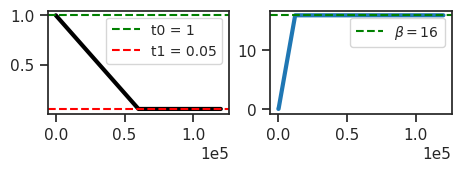

In [9]:
tr = Trainer(
    model=MODEL_CLASSES[model_type](CFG_CLASSES[model_type](**cfg_vae)),
    cfg=ConfigTrain(**cfg_tr),
    device=device,
)

tr.model.print()
tr.print()
tr.show_schedules()

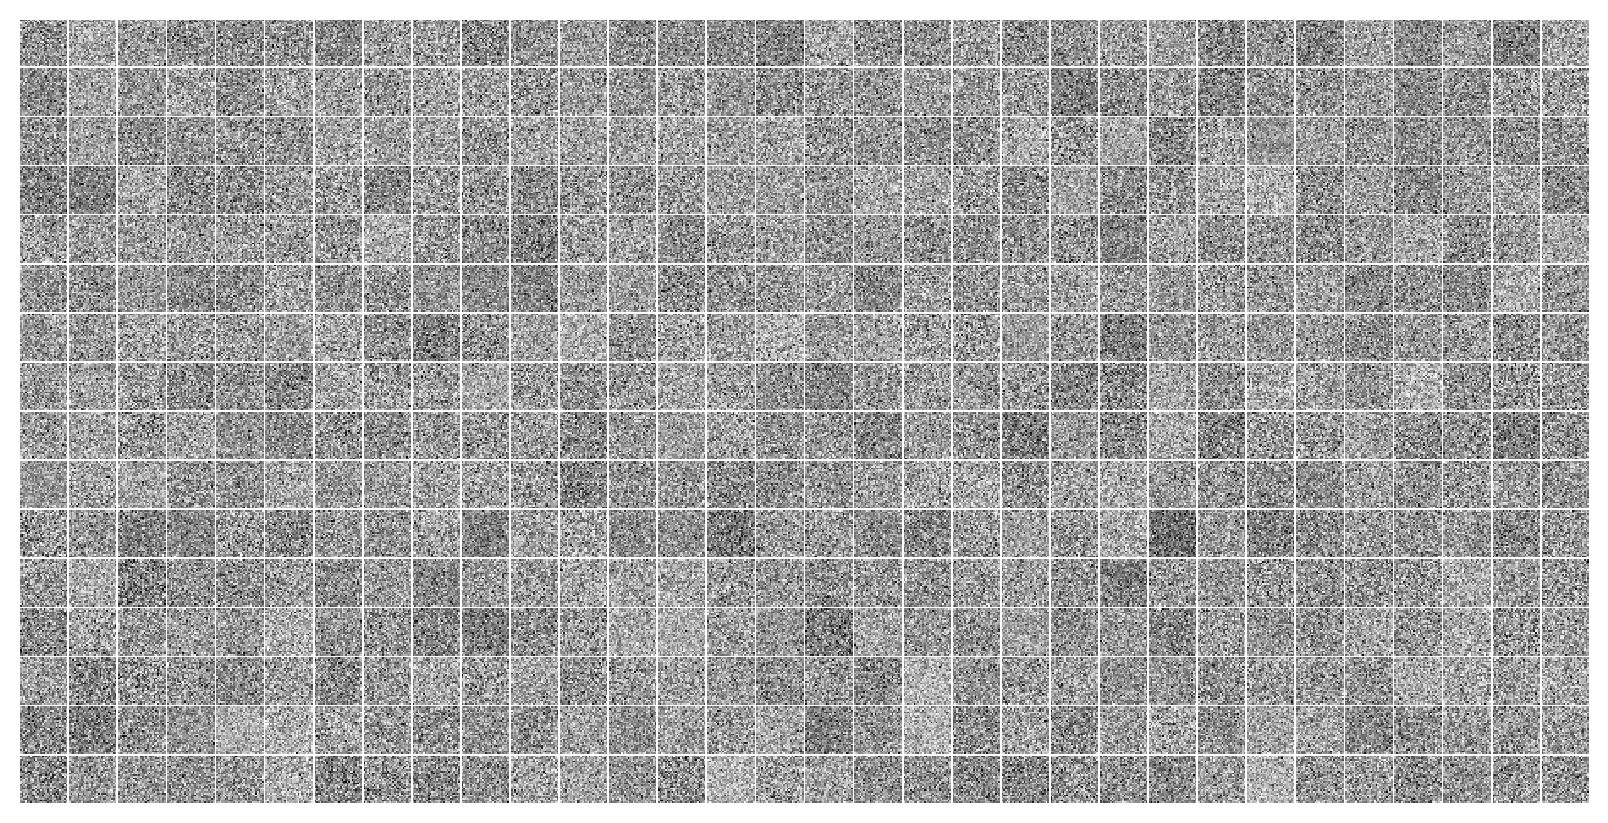

In [5]:
tr.model.show();

In [7]:
from base.common import *


def _build_mlp(
		input_dim: int,
		output_dim: int,
		activation_fn: str,
		n_hidden: int = 2,
		square_output: bool = False,
		final_bias: bool = False, ) -> nn.Sequential:
	factor = output_dim / input_dim
	factor = factor ** (1 / (n_hidden + 1))
	layers = []
	nch = input_dim
	for _ in range(n_hidden):
		next_nch = int(np.ceil(nch * factor))
		next_nch = nearest_power_of_two(next_nch)
		layers.extend([
			nn.Linear(nch, next_nch, bias=True),
			get_act_fn(activation_fn, inplace=True),
		])
		nch = next_nch
	if square_output:
		layers.extend([
			nn.Linear(nch, output_dim, bias=True),
			get_act_fn(activation_fn, inplace=True),
			nn.Linear(output_dim, output_dim, bias=final_bias),
		])
	else:
		layers.append(nn.Linear(nch, output_dim, bias=final_bias))
	return nn.Sequential(*layers)

In [8]:
mlp = _build_mlp(128, 784, 'swish', n_hidden=2)
print(mlp)

Sequential(
  (0): Linear(in_features=128, out_features=256, bias=True)
  (1): SiLU(inplace=True)
  (2): Linear(in_features=256, out_features=512, bias=True)
  (3): SiLU(inplace=True)
  (4): Linear(in_features=512, out_features=784, bias=False)
)

In [9]:
print_num_params(mlp)

+-------------+------------+
| Module Name | Num Params |
+-------------+------------+
|  Sequential |  566.0 K   |
|     ———     |    ———     |
|      0      |   33.0 K   |
|      2      |  131.6 K   |
|      4      |  401.4 K   |
+-------------+------------+

In [10]:
for m in mlp.modules():
    if hasattr(m, 'weight'):
        print(m)

Linear(in_features=128, out_features=256, bias=True)

Linear(in_features=256, out_features=512, bias=True)

Linear(in_features=512, out_features=784, bias=False)

In [11]:
from main.layers import LinearDictionary

In [12]:
dec = LinearDictionary(8, 53)

In [13]:
for m in dec.modules():
    if hasattr(m, 'weight'):
        print(m)

LinearDictionary()

In [3]:
a = 'Kyoto16-bw_m(g0+logi,p1)_t(16×(1,1))_b(8,8)_k(128,512)'
b = 'b200-ep800-lr(0.002)_temp(0.01:0.5)_gr(1000)_(2025_05_02,21:16)'
tr, meta = load_model(pjoin(a, b), device=device)
meta['checkpoint']

800

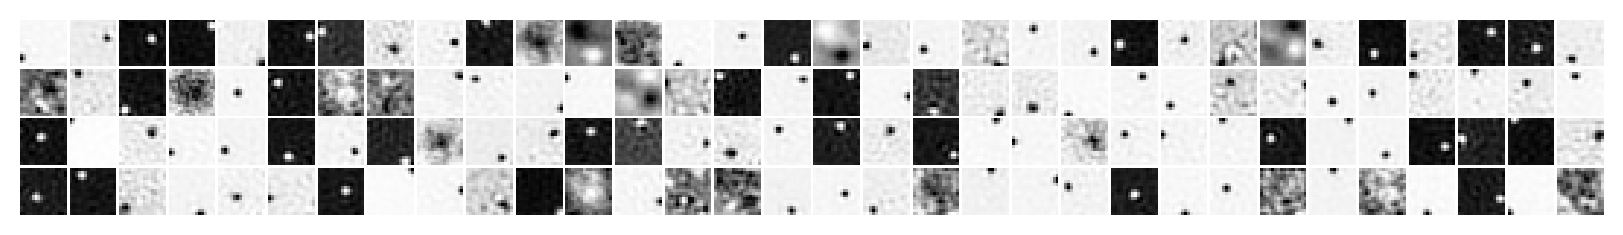

In [134]:
tr.model.show();

In [3]:
a = 'ImageNet32_m(g0+logi,p1)_t(16+64×(1,1))_b(128,96)_k(256,2048)'
b= 'fisher-xi-debug_b200-ep40-lr(0.0005)_temp(0.01:0.5)_gr(1000)_(2025_04_23,12:43)'
tr, meta = load_model(pjoin(a, b), device=device)
meta['checkpoint']

40

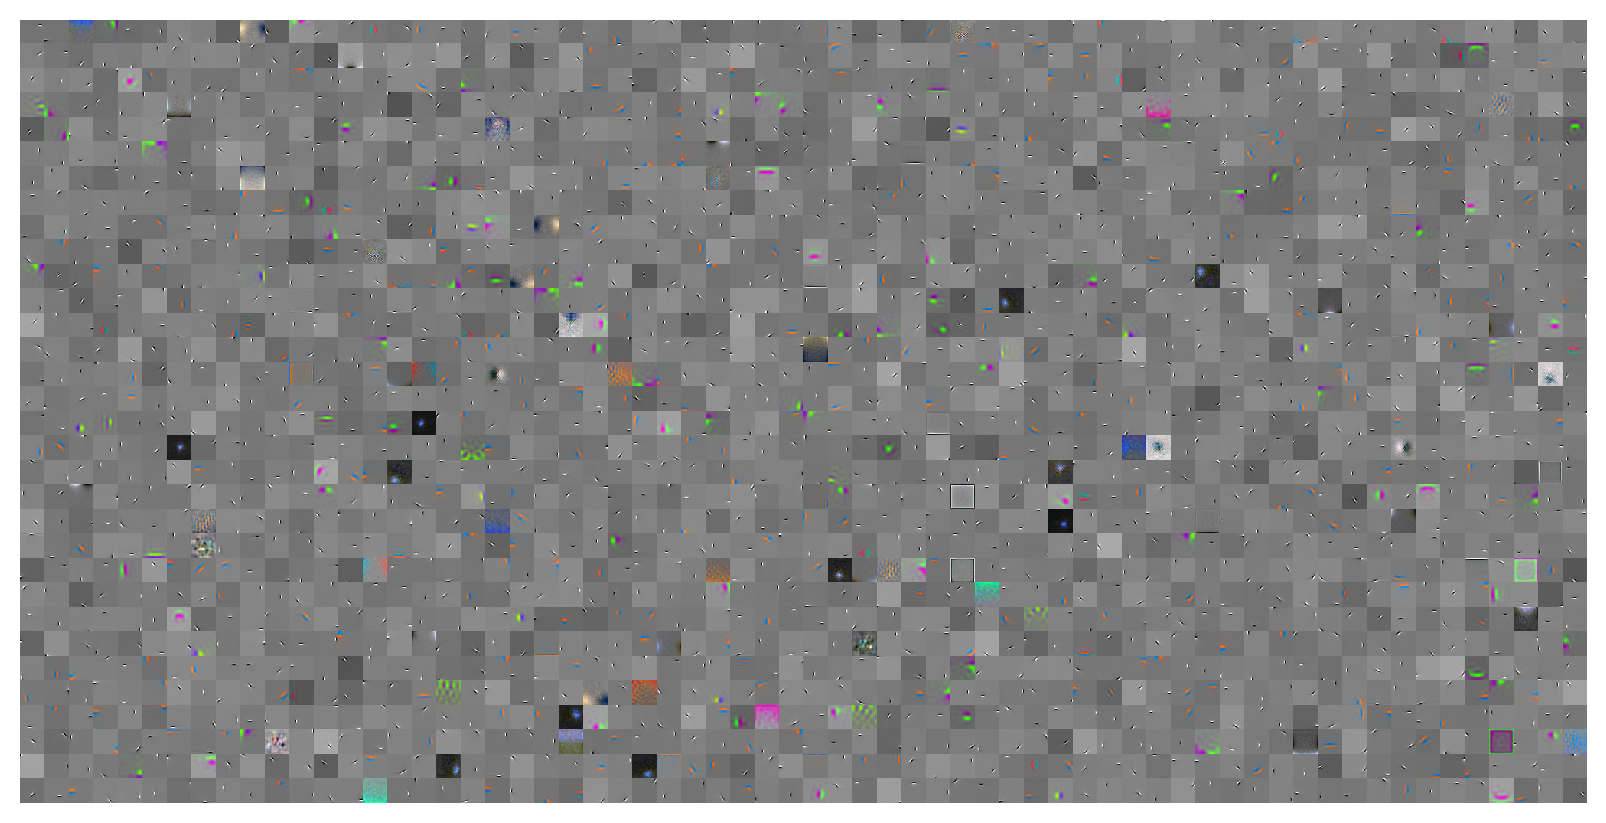

In [5]:
tr.model.show('p1');

In [8]:
tr.model.cfg.cfg_layers

{'g0': {'n_latents': 256,
  't_repeats': 1,
  'beta_outer': 128.0,
  'beta_inner': 1.0,
  'n_iters_inner': 1,
  'latent_act': 'logistic',
  'clamp_u': [7.0, 2.0],
  'clamp_du': [7.0, 3.0],
  'init_dist': 'normal',
  'init_scale': 0.0001,
  'stochastic': True,
  'fit_prior': True,
  't_train': 64,
  'seed': 0},
 'p1': {'prior_log_dist': 'uniform',
  'clamp_prior': -2.0,
  'n_latents': 2048,
  't_repeats': 1,
  'beta_outer': 96.0,
  'beta_inner': 1.0,
  'n_iters_inner': 1,
  'latent_act': None,
  'clamp_u': 4.5,
  'clamp_du': 7.0,
  'init_dist': 'normal',
  'init_scale': 0.0001,
  'stochastic': True,
  'fit_prior': True,
  't_train': 64,
  'seed': 0}}

In [9]:
np.exp(4.5)

90.01713130052181

In [10]:
output = tr.xtract_ftr(n_data_batches=1)

100%|███████████████████████████████████| 1/1 [00:05<00:00,  5.42s/it]


In [11]:
list(output)

['g0', 'p1', 'times']

In [17]:
state = output['p1']['state'][:, -1]
spks = output['p1']['samples'][:, -1]

state.shape, spks.shape

((200, 2048), (200, 2048))

In [16]:
(spks == 0).mean()

0.82651611328125

In [18]:
state

array([[-8.000004  , -7.2765007 , -8.000004  , ..., -8.000004  ,
        -1.7003627 , -7.9652653 ],
       [-4.905386  , -7.950346  , -7.7411985 , ..., -7.90532   ,
        -4.113594  , -8.000004  ],
       [-8.000004  , -8.000004  , -8.000004  , ..., -8.000004  ,
        -8.000004  , -1.3525968 ],
       ...,
       [-0.74131536, -8.000004  , -7.8326693 , ..., -8.000004  ,
        -0.39536715, -7.9897842 ],
       [-7.998725  , -7.994276  , -8.000004  , ..., -1.7055335 ,
        -0.42608356, -7.9878273 ],
       [-8.000004  , -8.000004  , -7.1276464 , ..., -0.5671034 ,
        -7.754218  ,  1.001647  ]], dtype=float32)

In [19]:
state.max()

3.0860877

In [21]:
np.ln(100)

AttributeError: module 'numpy' has no attribute 'ln'